In [1]:
# notebook debugging preamble
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [2]:
df = pd.read_csv("./data.csv", index_col=0, sep=",")

In [3]:
df

,x1,x2,x3,y
id,,,,
1,1,1,0,3
2,1,2,1,6
3,1,3,0,4
4,1,4,1,7
5,2,1,1,5
6,2,2,0,6
7,2,3,1,9
8,2,4,0,7
9,3,1,0,8


In [4]:
X = df[["x1", "x2", "x3"]].values.astype(np.float32)
y = df["y"].values

In [5]:
X, y

(array([[1., 1., 0.],
        [1., 2., 1.],
        [1., 3., 0.],
        [1., 4., 1.],
        [2., 1., 1.],
        [2., 2., 0.],
        [2., 3., 1.],
        [2., 4., 0.],
        [3., 1., 0.],
        [3., 2., 1.],
        [3., 3., 0.],
        [3., 4., 1.],
        [4., 1., 1.],
        [4., 2., 0.],
        [4., 3., 1.],
        [4., 4., 0.],
        [5., 1., 0.],
        [5., 2., 1.],
        [5., 3., 0.],
        [5., 4., 1.]], dtype=float32),
 array([ 3,  6,  4,  7,  5,  6,  9,  7,  8,  9,  8, 12, 10,  9, 13, 12, 10,
        12, 14, 14]))

In [6]:
reg = LinearRegression().fit(X, y)

In [7]:
reg.score(X, y)

0.9361337174889672

In [8]:
beta = np.concatenate(
    [
        np.array([reg.intercept_]),
        reg.coef_,
    ]
)

In [9]:
y_pred = reg.predict(X)

In [10]:
residual_variance = mean_squared_error(y, y_pred)

In [11]:
residual_variance

0.6380241622852167

In [12]:
X_expand = np.column_stack([np.ones(X.shape[0]), X])

In [13]:
var_beta = residual_variance * np.linalg.inv(X_expand.T @ X_expand)

In [14]:
se_beta = np.sqrt(np.diag(var_beta))

In [15]:
se_beta

array([0.5962752 , 0.1262957 , 0.1603957 , 0.35865569])

In [16]:
t_beta = beta / se_beta

In [17]:
np.abs(t_beta)

array([ 0.22316236, 15.24200885,  6.38541906,  3.8899739 ])

In [18]:
features = [
    "(intercept)",
    "Study hours",
    "Number of practice exercises",
    "Sleep quality",
]

In [19]:
df_importance = pd.DataFrame(index=features)

In [20]:
df_importance["weight"] = beta
df_importance["se"] = se_beta
df_importance["t"] = np.abs(t_beta)

In [21]:
df_importance

,weight,se,t
(intercept),-0.133066,0.596275,0.223162
Study hours,1.925000,0.126296,15.242009
Number of practice exercises,1.024194,0.160396,6.385419
Sleep quality,1.395161,0.358656,3.889974


## PDP

In [30]:
def PDP(feature_id, reg, X, grid_resolution=50):
    import copy

    """select the feature id as x_s and compute the partial dependence function"""
    assert feature_id in range(X.shape[0]), "feature id out of range"
    xs_grid = np.linspace(0, 5, grid_resolution)
    ys_grid = np.empty_like(xs_grid)
    for i, xs_value in enumerate(xs_grid):
        X_ = copy.deepcopy(X)
        X_[:, feature_id] = np.ones(X.shape[0]) * xs_value
        ys = reg.predict(X_)
        ys_grid[i] = ys.mean()
    return xs_grid, ys_grid

In [31]:
def plot_PDP(feature_id, reg, X, features):
    xs_grid, ys_grid = PDP(0, reg, X)
    plt.plot(xs_grid, ys_grid)

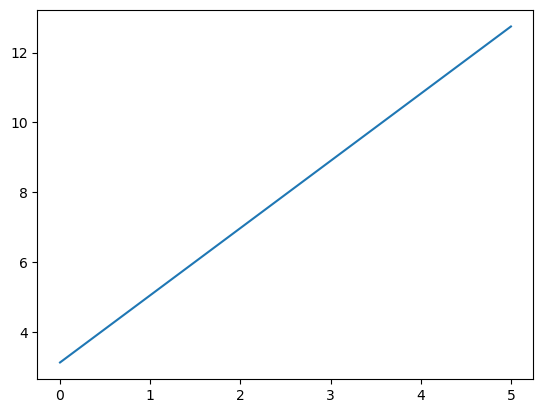

In [32]:
plot_PDP(0, reg, X, features)

In [33]:
from sklearn.inspection import PartialDependenceDisplay

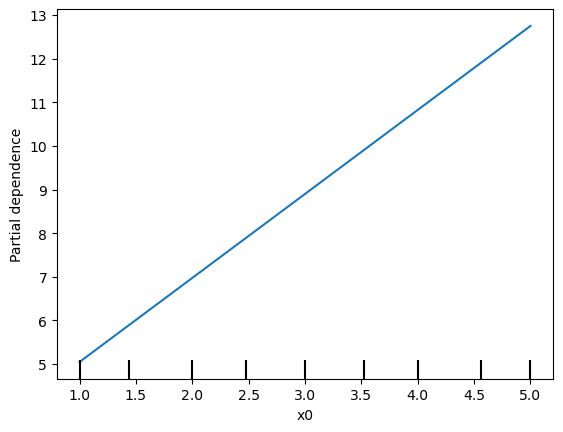

In [34]:
PartialDependenceDisplay.from_estimator(reg, X, [0], grid_resolution=50)

## Shapley values